In [1]:
# ============================================================
# PHASE 5: FEATURE ENGINEERING
# Creating new features from domain knowledge
# Goal: Give the model better signals than raw data alone
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the ORIGINAL cleaned data (before encoding)
# We engineer features BEFORE encoding, on readable data
df = pd.read_csv('../data/processed/telco_cleaned_v1.csv')

# Fix TotalCharges again (since we're starting fresh)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df.drop(columns=['customerID'], inplace=True)

print("Shape:", df.shape)
print("Ready for feature engineering.")

Shape: (7043, 20)
Ready for feature engineering.


In [2]:
# ============================================================
# FEATURE 1: tenure_group
# Why: Raw tenure (0-72) is less informative than lifecycle stage
# New customers behave very differently from loyal ones
# ============================================================

def assign_tenure_group(tenure):
    if tenure <= 12:
        return 'New'          # High churn risk
    elif tenure <= 24:
        return 'Developing'   # Moderate risk
    elif tenure <= 48:
        return 'Established'  # Lower risk
    else:
        return 'Loyal'        # Very low risk

df['tenure_group'] = df['tenure'].apply(assign_tenure_group)

# Validate: check churn rate by tenure group
print("Churn rate by tenure group:")
print(df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).round(3).sort_values(ascending=False))

Churn rate by tenure group:
tenure_group
New            0.474
Developing     0.287
Established    0.204
Loyal          0.095
Name: Churn, dtype: float64


In [3]:
# ============================================================
# FEATURE 2: num_services
# Why: Customers using more services are more "sticky"
# They have higher switching costs — less likely to churn
# ============================================================

service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count how many services each customer has (Yes = 1, else = 0)
df['num_services'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)

print("num_services distribution:")
print(df['num_services'].value_counts().sort_index())
print("\nChurn rate by number of services:")
print(df.groupby('num_services')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).round(3))

num_services distribution:
num_services
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

Churn rate by number of services:
num_services
0    0.438
1    0.211
2    0.328
3    0.365
4    0.313
5    0.256
6    0.225
7    0.124
8    0.053
Name: Churn, dtype: float64


In [4]:
# ============================================================
# FEATURE 3: avg_monthly_spend_rate
# Why: TotalCharges / tenure captures consistency of spend
# A customer paying more recently than their history → risk signal
# ============================================================

# Avoid division by zero with + 1
df['avg_monthly_spend_rate'] = df['TotalCharges'] / (df['tenure'] + 1)

# Also create charge increase indicator
# MonthlyCharges >> avg historical spend = customer on expensive plan
df['charge_increase_flag'] = (
    df['MonthlyCharges'] > df['avg_monthly_spend_rate'] * 1.1
).astype(int)

print("avg_monthly_spend_rate stats:")
print(df['avg_monthly_spend_rate'].describe().round(2))
print("\nChurn rate - charge increased:", 
      df[df['charge_increase_flag']==1]['Churn'].apply(lambda x: x=='Yes').mean().round(3))
print("Churn rate - charge stable  :", 
      df[df['charge_increase_flag']==0]['Churn'].apply(lambda x: x=='Yes').mean().round(3))

avg_monthly_spend_rate stats:
count    7043.00
mean       58.99
std        30.58
min         0.00
25%        26.04
50%        60.94
75%        84.83
max       118.97
Name: avg_monthly_spend_rate, dtype: float64

Churn rate - charge increased: 0.466
Churn rate - charge stable  : 0.181


In [5]:
# ============================================================
# FEATURE 4: is_high_risk
# Why: Combines top 3 churn signals from EDA into one feature
# Month-to-month + Fiber optic + Electronic check = danger zone
# ============================================================

df['is_high_risk'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

print("High risk customers:", df['is_high_risk'].sum())
print("Churn rate - high risk :", 
      df[df['is_high_risk']==1]['Churn'].apply(lambda x: x=='Yes').mean().round(3))
print("Churn rate - normal    :", 
      df[df['is_high_risk']==0]['Churn'].apply(lambda x: x=='Yes').mean().round(3))

High risk customers: 1307
Churn rate - high risk : 0.604
Churn rate - normal    : 0.188


In [6]:
# ============================================================
# FEATURE 5: vulnerability_score
# Why: Senior citizens with no social ties (no partner,
#      no dependents) are more likely to churn
# Captures isolation as a churn predictor
# ============================================================

df['SeniorCitizen_num'] = df['SeniorCitizen']  # already 0/1

df['vulnerability_score'] = (
    df['SeniorCitizen_num'] +
    (df['Partner'] == 'No').astype(int) +
    (df['Dependents'] == 'No').astype(int)
)
# Score 0 = low vulnerability, Score 3 = most vulnerable

print("Vulnerability score distribution:")
print(df['vulnerability_score'].value_counts().sort_index())
print("\nChurn rate by vulnerability score:")
print(df.groupby('vulnerability_score')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).round(3))

Vulnerability score distribution:
vulnerability_score
0    1666
1    1599
2    3217
3     561
Name: count, dtype: int64

Churn rate by vulnerability score:
vulnerability_score
0    0.137
1    0.211
2    0.319
3    0.492
Name: Churn, dtype: float64


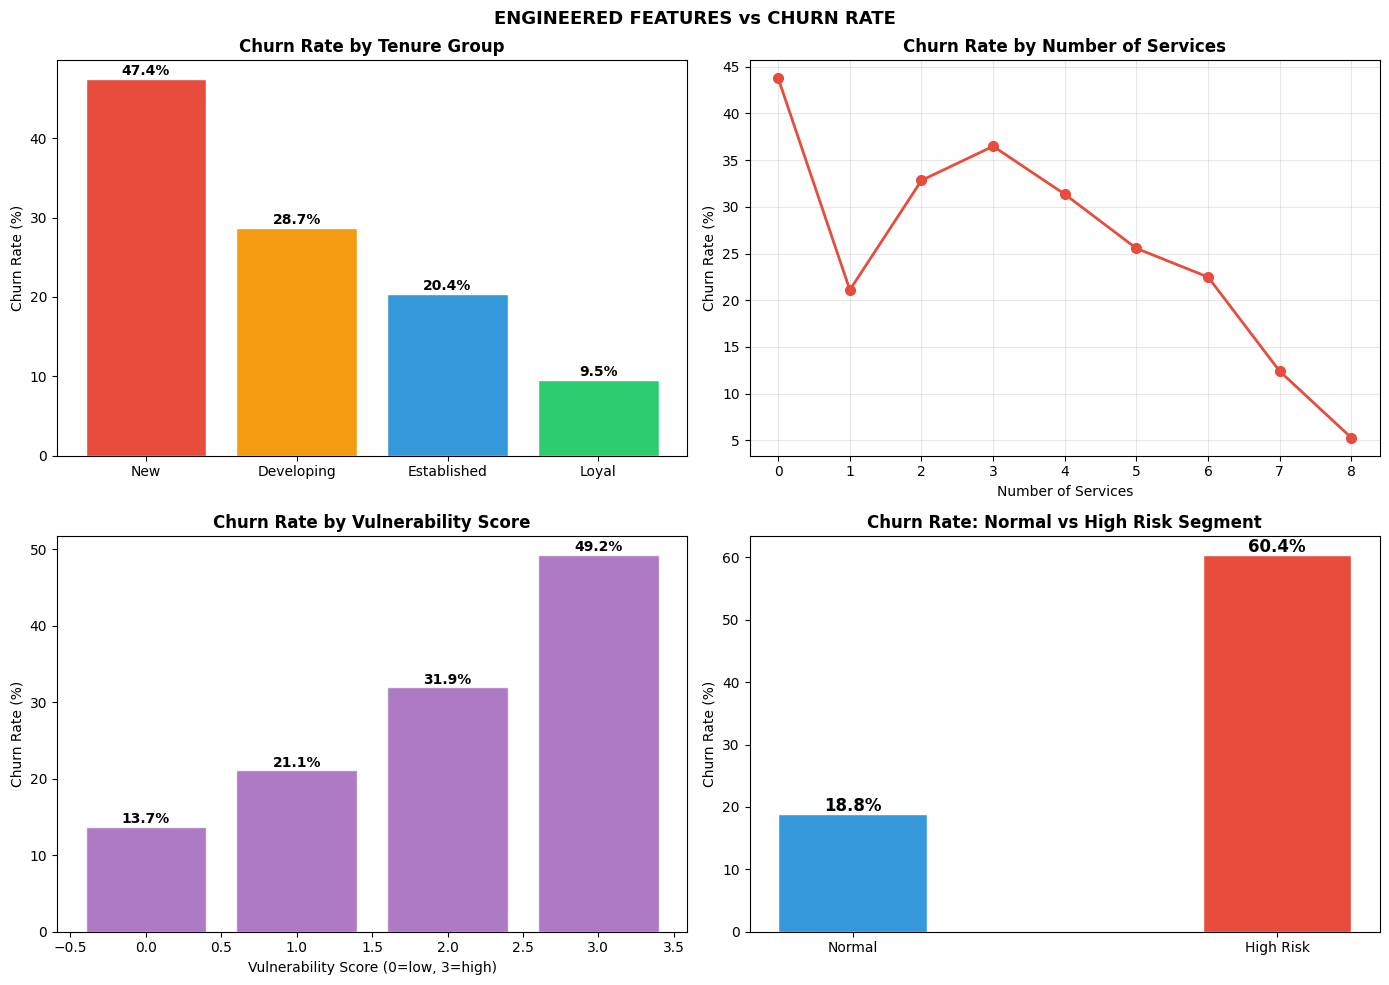

In [7]:
# ============================================================
# VISUALIZE: How well do engineered features predict churn?
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn rate by tenure group
tenure_order = ['New', 'Developing', 'Established', 'Loyal']
tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(tenure_order)

axes[0,0].bar(tenure_churn.index, tenure_churn.values,
              color=['#e74c3c','#f39c12','#3498db','#2ecc71'],
              edgecolor='white')
for i, v in enumerate(tenure_churn.values):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0,0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')

# 2. Churn rate by num_services
svc_churn = df.groupby('num_services')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
axes[0,1].plot(svc_churn.index, svc_churn.values,
               marker='o', color='#e74c3c', linewidth=2, markersize=7)
axes[0,1].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[0,1].set_xlabel('Number of Services')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].grid(True, alpha=0.3)

# 3. Vulnerability score vs churn
vuln_churn = df.groupby('vulnerability_score')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
axes[1,0].bar(vuln_churn.index, vuln_churn.values,
              color='#9b59b6', edgecolor='white', alpha=0.8)
for i, v in enumerate(vuln_churn.values):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,0].set_title('Churn Rate by Vulnerability Score', fontweight='bold')
axes[1,0].set_xlabel('Vulnerability Score (0=low, 3=high)')
axes[1,0].set_ylabel('Churn Rate (%)')

# 4. High risk flag impact
risk_labels = ['Normal', 'High Risk']
risk_values = [
    df[df['is_high_risk']==0]['Churn'].apply(lambda x: x=='Yes').mean()*100,
    df[df['is_high_risk']==1]['Churn'].apply(lambda x: x=='Yes').mean()*100
]
axes[1,1].bar(risk_labels, risk_values,
              color=['#3498db','#e74c3c'], edgecolor='white', width=0.35)
for i, v in enumerate(risk_values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1,1].set_title('Churn Rate: Normal vs High Risk Segment', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')

plt.suptitle('ENGINEERED FEATURES vs CHURN RATE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_engineered_features.png', bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# FULL PIPELINE: Encode + Scale everything including new features
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib, os

# --- Binary encode Yes/No columns ---
binary_cols = ['gender','Partner','Dependents','PhoneService',
               'PaperlessBilling','MultipleLines','OnlineSecurity',
               'OnlineBackup','DeviceProtection','TechSupport',
               'StreamingTV','StreamingMovies']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# --- Encode target ---
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# --- One-Hot Encode multi-category + new categorical feature ---
ohe_cols = ['InternetService', 'Contract', 'PaymentMethod', 'tenure_group']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# --- Split ---
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Scale numeric features ---
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'num_services', 'avg_monthly_spend_rate', 'vulnerability_score']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# --- Save ---
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

X_train.to_csv('../data/processed/X_train_fe.csv', index=False)
X_test.to_csv('../data/processed/X_test_fe.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
joblib.dump(scaler, '../models/scaler_fe.pkl')

print("Saved feature-engineered datasets.")
print("Final feature count:", X_train.shape[1])
print("Training samples   :", X_train.shape[0])
print("Test samples       :", X_test.shape[0])

Saved feature-engineered datasets.
Final feature count: 32
Training samples   : 5634
Test samples       : 1409


In [9]:
print("""
╔══════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║ 5 new features created:                                  ║
║                                                          ║
║ 1. tenure_group      → lifecycle stage (New/Loyal etc)   ║
║ 2. num_services      → count of active services          ║
║ 3. avg_monthly_spend → TotalCharges / (tenure+1)         ║
║ 4. charge_increase_flag → sudden billing spike           ║
║ 5. is_high_risk      → contract+internet+payment combo   ║
║ 6. vulnerability_score → senior + alone customers        ║
║                                                          ║
║ These features encode domain knowledge the model         ║
║ cannot learn from raw data alone.                        ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║ 5 new features created:                                  ║
║                                                          ║
║ 1. tenure_group      → lifecycle stage (New/Loyal etc)   ║
║ 2. num_services      → count of active services          ║
║ 3. avg_monthly_spend → TotalCharges / (tenure+1)         ║
║ 4. charge_increase_flag → sudden billing spike           ║
║ 5. is_high_risk      → contract+internet+payment combo   ║
║ 6. vulnerability_score → senior + alone customers        ║
║                                                          ║
║ These features encode domain knowledge the model         ║
║ cannot learn from raw data alone.                        ║
╚══════════════════════════════════════════════════════════╝

